# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime
import os
import sys
import shap
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    fit_gapfill_ts,
    build_df_for_parcel,
    apply_gapfill_ts,
    plot_gapfill_dashboard,
    merge_gapfill_results
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FCH4'
RAND_ERR_COL = "FCH4_RANDUNC_HF"  # EddyPro random uncertainty col
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True
SHAP_CHECK = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')

# Make a copy of the original data for later use
maindf = data_main.copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data_main = data_main[data_main['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (0.110 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 13776 of 13776 records (2024-08-22 00:15:00 to 2025-06-04 23:45:00, timestamp=middle)

Keeping only data when we are highly confident on the parcel attribution


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FCH4_RANDUNC_HF,SW_IN_POT,prec,ta,...,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,4.791627,0.475098,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,3.101760,0.0,0.000,11.276667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0
2024-08-22 00:45:00,4.565958,0.662601,25.160860,25.160860,NaN,NaN,NaN,NaN,A,certain,0.0,10.141500,0.0,0.000,11.043333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1
2024-08-22 01:45:00,4.323735,0.851883,7.098940,NaN,NaN,7.098940,NaN,NaN,A,certain,0.0,4.334050,0.0,0.000,10.720000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,3
2024-08-22 02:15:00,4.323735,0.868263,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,2.064620,0.0,0.000,10.820000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,4
2024-08-22 02:45:00,4.494796,0.677546,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,21.954500,0.0,0.000,10.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,-0.970199,2.489636,2.489636,2.489636,NaN,NaN,NaN,B,certain,1.0,1.174440,0.0,0.017,15.693333,...,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,4.389574,39.079782,13771
2025-06-04 22:15:00,9.416519,0.146401,-0.987718,-0.987718,-0.987718,NaN,NaN,NaN,B,certain,1.0,0.734541,0.0,0.034,15.516667,...,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,4.393382,39.111514,13772
2025-06-04 22:45:00,10.095010,-0.495217,2.160966,2.160966,2.160966,2.160966,2.160966,2.160966,B,certain,1.0,1.057590,0.0,0.425,15.660000,...,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,4.397189,39.143246,13773


# SELECT FEATURES

In [4]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')


The treatment variable (trt) is included in the feature set


# SELECT MODEL

In [5]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1)
    else:
        return XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.7755885682822544, 'gamma': 0.03922819067113298, 'learning_rate': 0.007535074341545751, 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 226, 'subsample': 0.8783896824374792}


# GAP-FILLING

## CUT-16

In [6]:
USTAR_CUT = 'CUT_16'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FCH4_L3.3_CUT_16_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: raw empirical (cvm distance 8.4188; raw baseline 8.4188)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 164/1364 rows never held out (12.0%); mean times held out 2.02
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_16_QCF0
  RMSE:   13.7596
  MAE:    8.4690
  R2:     -0.0551
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: raw empirical (cvm distance 7.8678; raw baseline 7.8678)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.098-0.107
  Coverage: 174/1557 rows never held out (11.2%); mean times held out 2.03


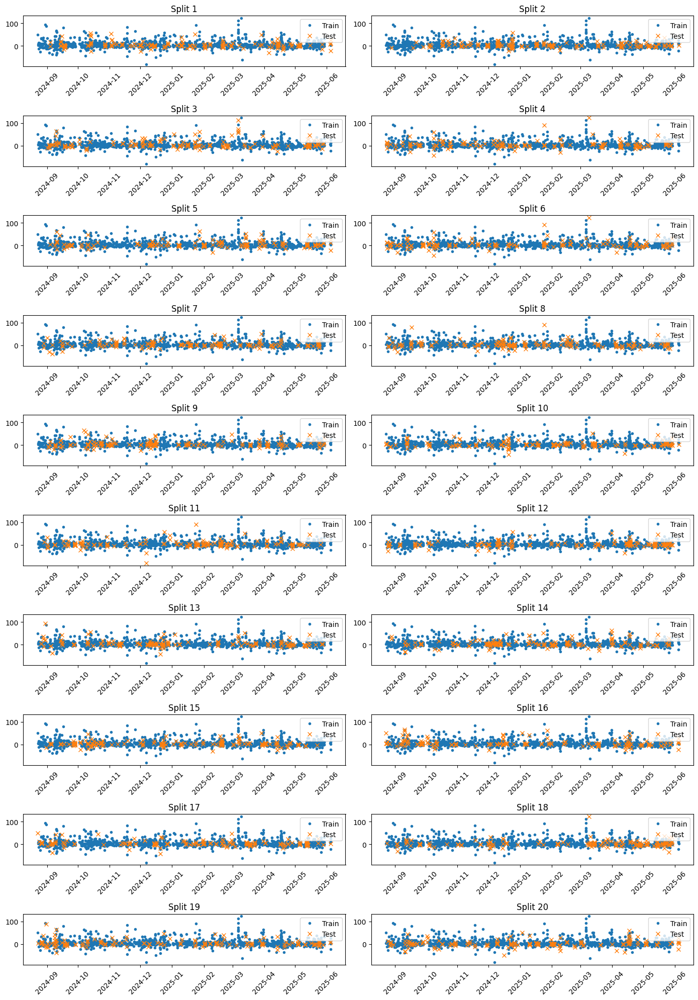

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_16_QCF0
  RMSE:   13.7757
  MAE:    8.8028
  R2:     0.0069
----------------------------------------
Fitting final model on full training set...


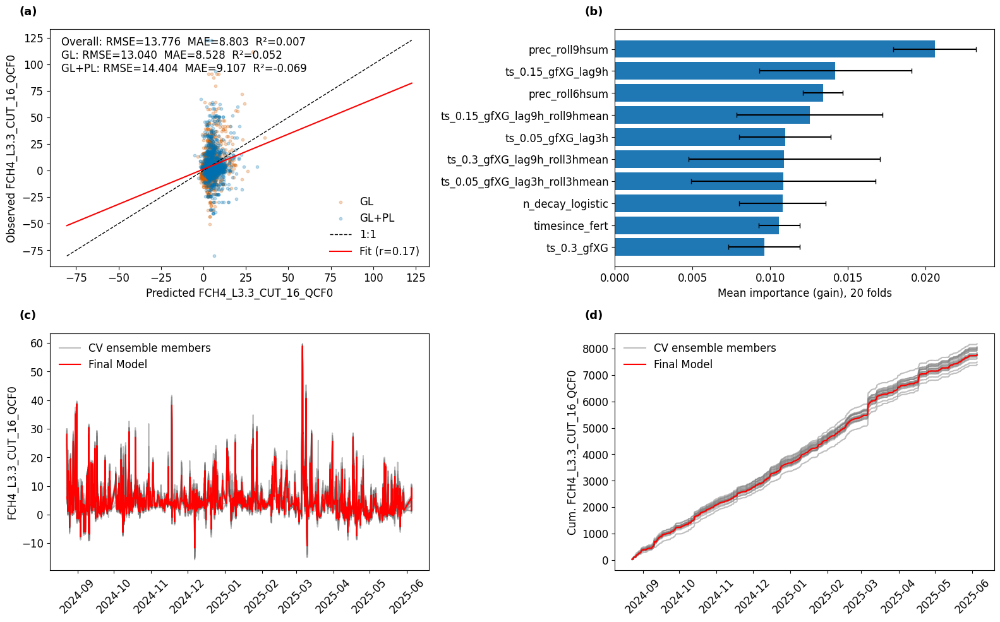

Finished training. Ensemble size (folds): 20


In [7]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

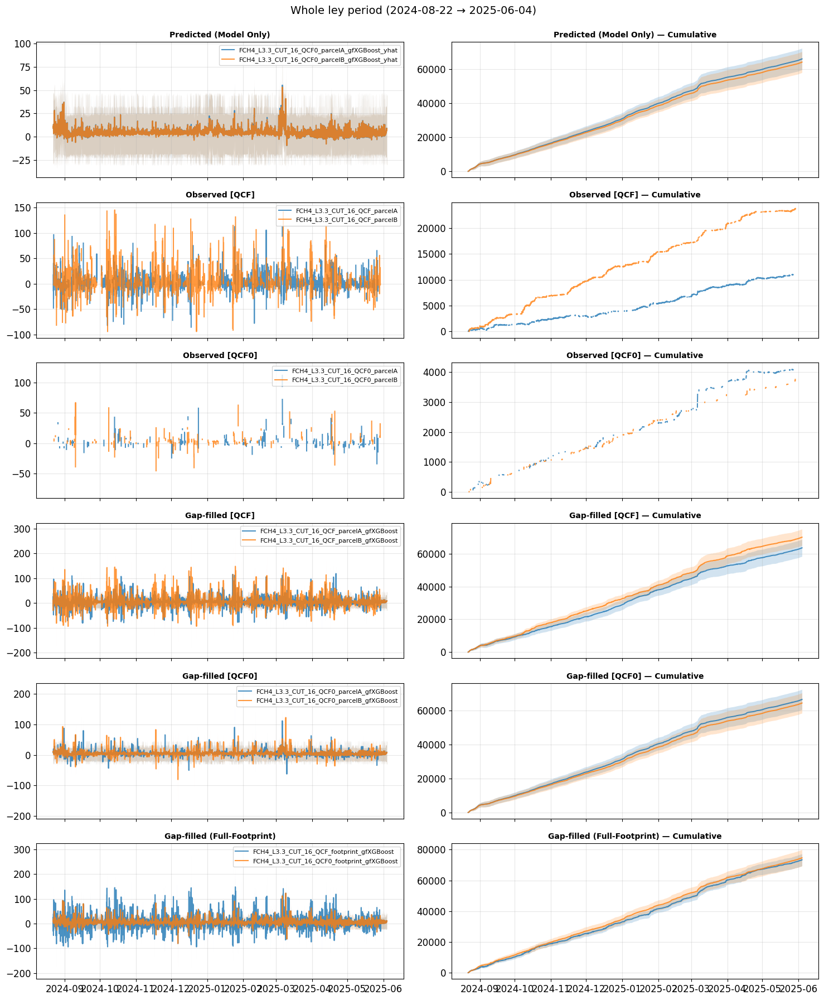

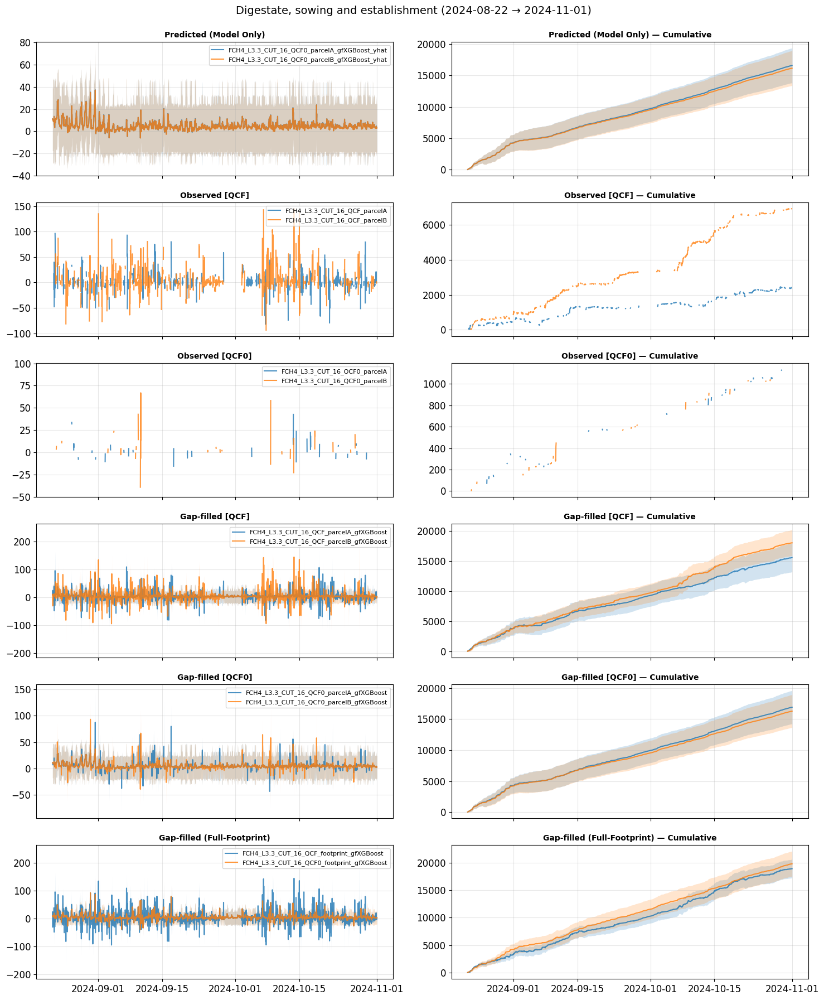

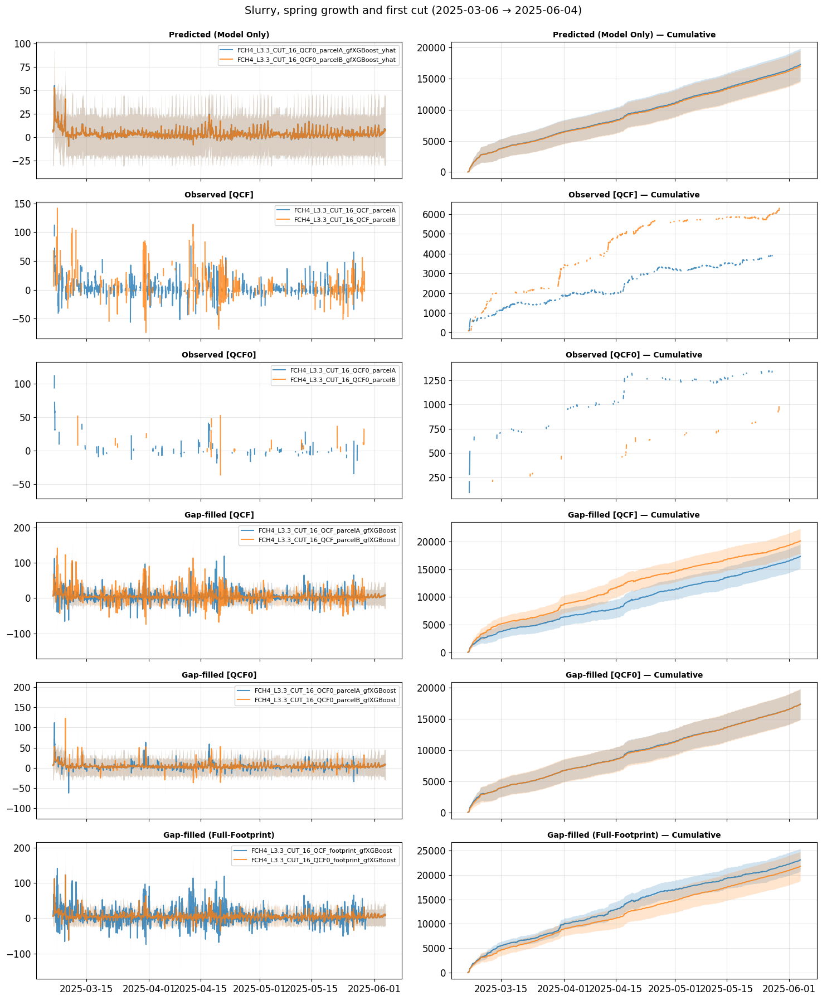

In [8]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target=TARGET,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT16
df_CUT16 = df_final.copy()

## CUT-50

In [9]:
USTAR_CUT = 'CUT_50'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FCH4_L3.3_CUT_50_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: raw empirical (cvm distance 6.9833; raw baseline 6.9833)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.101-0.106
  Coverage: 159/1320 rows never held out (12.0%); mean times held out 2.04
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_50_QCF0
  RMSE:   12.8435
  MAE:    8.4046
  R2:     -0.0261
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: raw empirical (cvm distance 7.2736; raw baseline 7.2736)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.105
  Coverage: 202/1502 rows never held out (13.4%); mean times held out 2.03


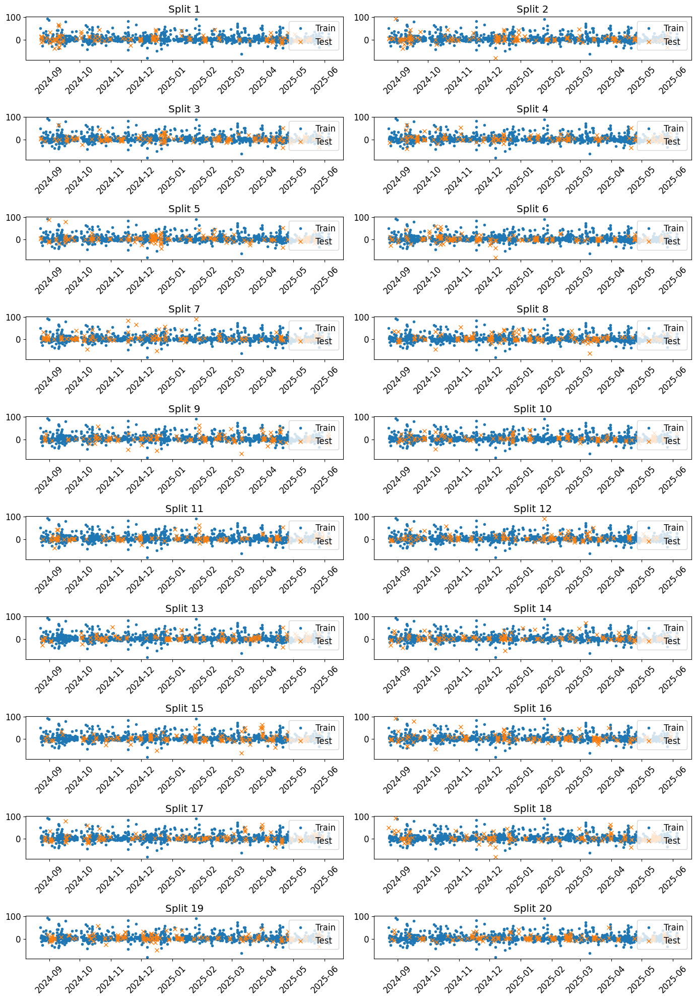

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_50_QCF0
  RMSE:   14.3761
  MAE:    9.2045
  R2:     -0.0134
----------------------------------------
Fitting final model on full training set...


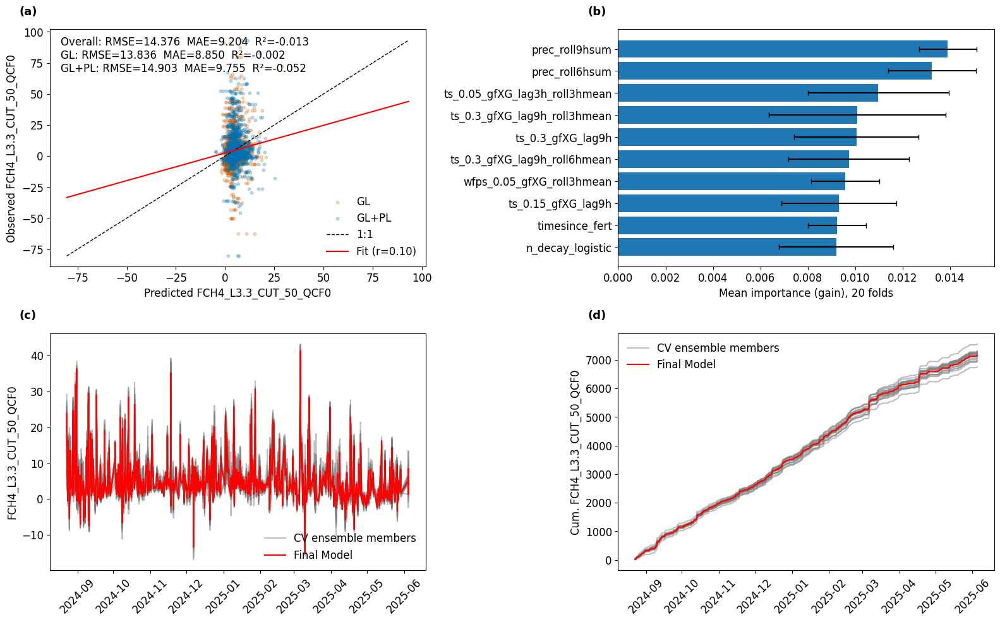

Finished training. Ensemble size (folds): 20


In [10]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

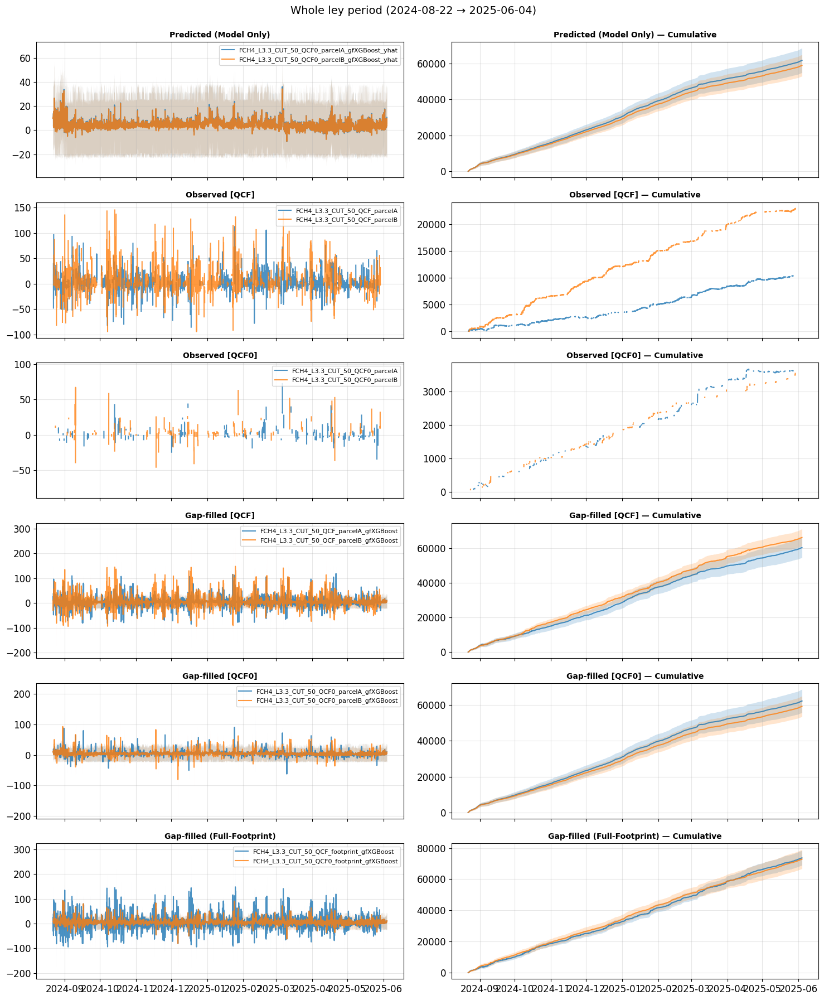

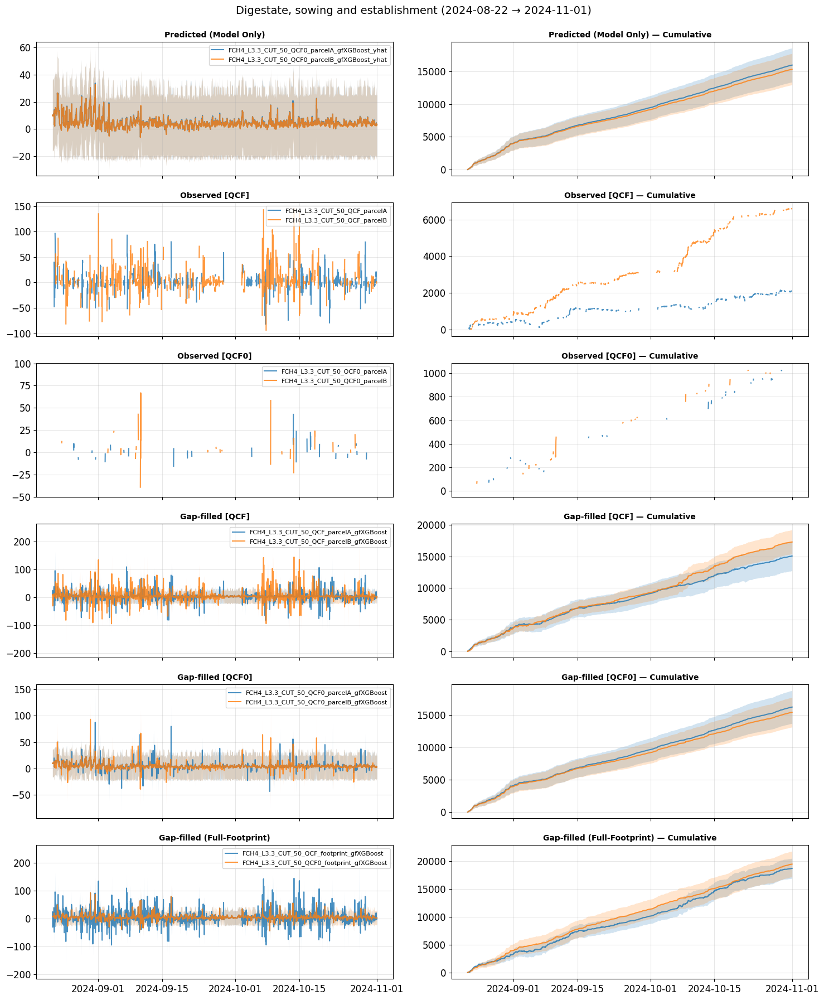

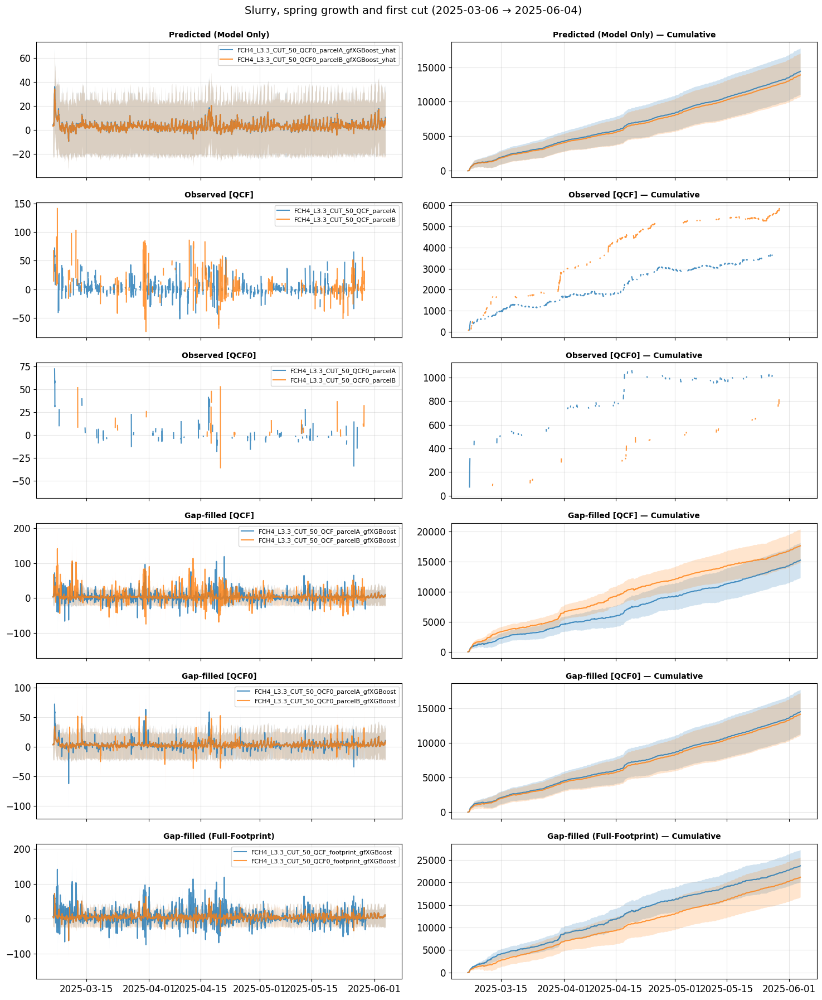

In [11]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT50
df_CUT50 = df_final.copy()

### SHAP CHECK

  6%|=                   | 661/11498 [00:11<03:00]       

  6%|=                   | 710/11498 [00:12<03:02]       

  7%|=                   | 776/11498 [00:13<02:59]       

  7%|=                   | 852/11498 [00:14<02:54]       

  8%|==                  | 919/11498 [00:15<02:52]       

...

 97%|=================== | 11146/11498 [02:33<00:04]       

 98%|===================| 11230/11498 [02:34<00:03]       

 98%|===================| 11306/11498 [02:35<00:02]       

 99%|===================| 11381/11498 [02:36<00:01]       

100%|===================| 11455/11498 [02:37<00:00]       

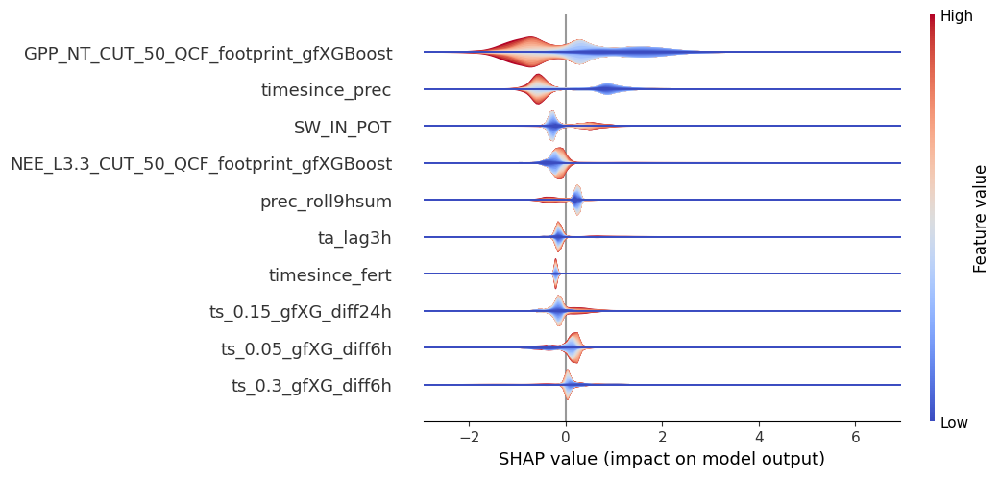

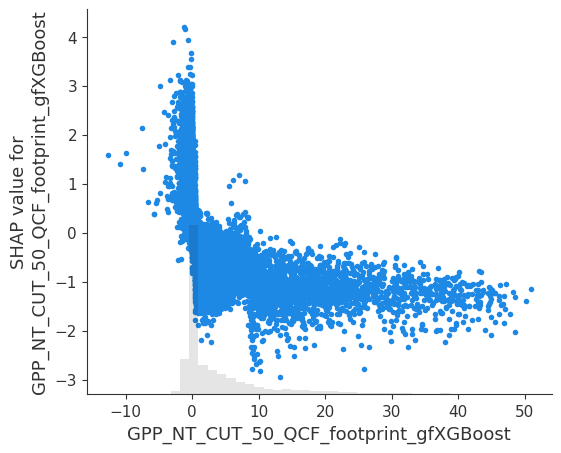

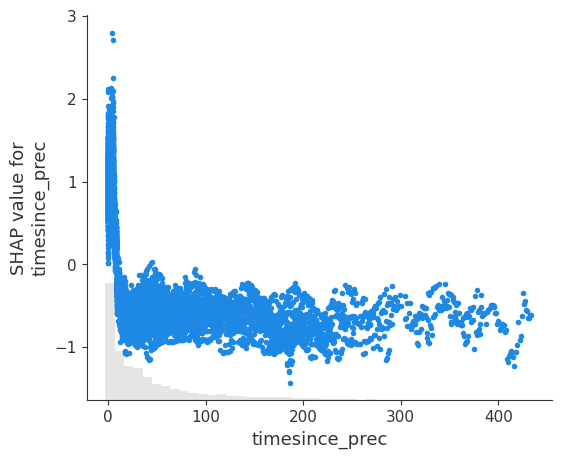

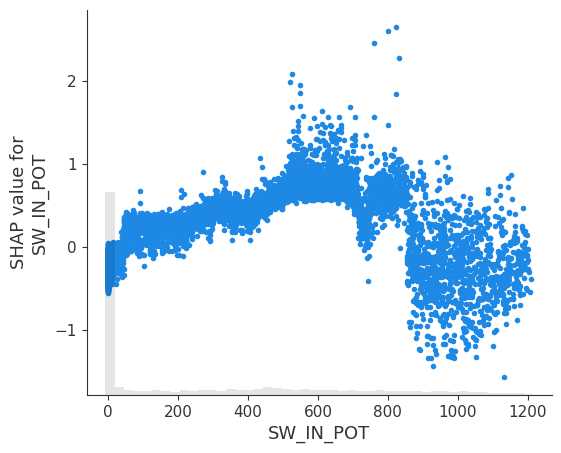

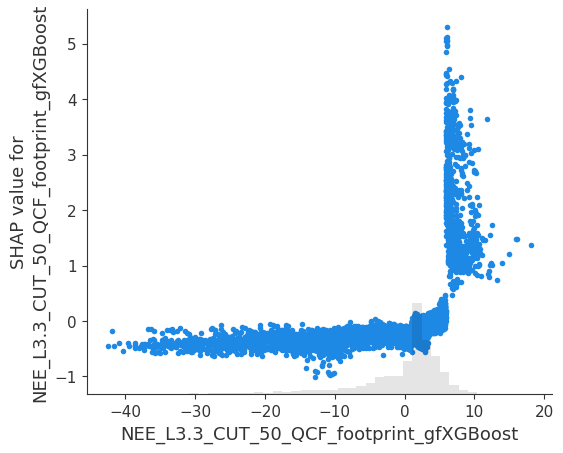

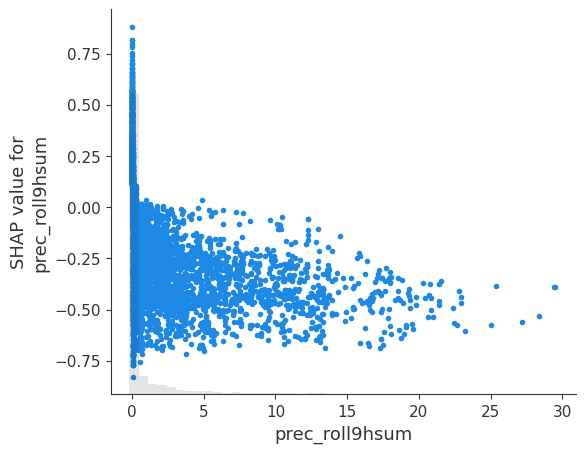

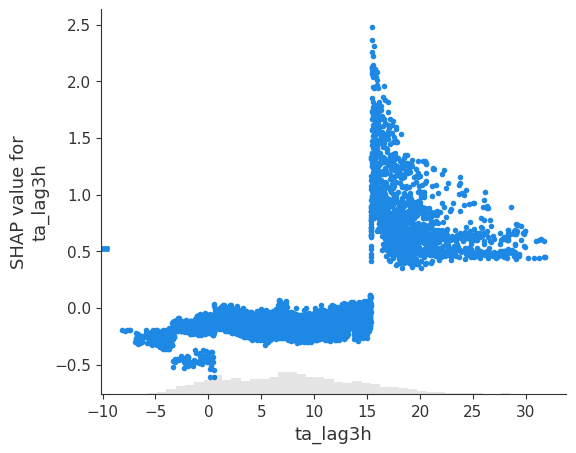

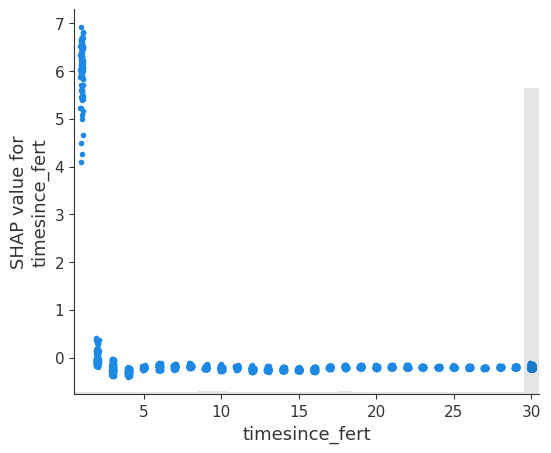

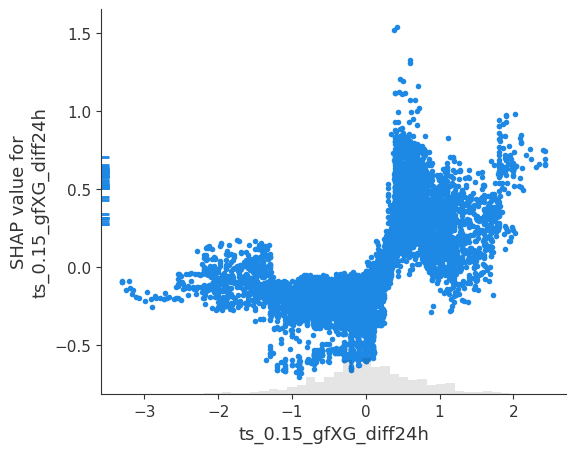

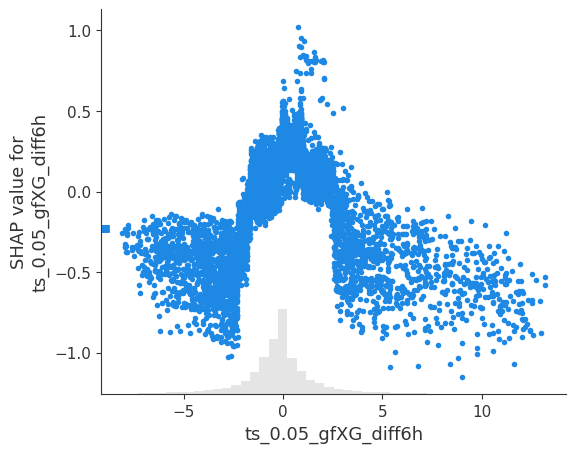

In [12]:
if SHAP_CHECK:

    # Initialize the SHAP explainer
    X = data_main[selected_features]
    explainer = shap.TreeExplainer(fit.model_final, data=X)

    # Calculate SHAP values
    shap_values = explainer(X, check_additivity=True)

    # Violin summary plot for top 10 features
    shap.plots.violin(shap_values, features=X, plot_type="layered_violin", max_display=10)
    plt.show()

    # Scatter plots of top 10 most important features
    for i in range(-1, -10, -1):
        shap.plots.scatter(shap_values[:, shap_values.abs.mean(0).argsort[i]])
        plt.show()

## CUT-84

In [13]:
USTAR_CUT = 'CUT_84'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FCH4_L3.3_CUT_84_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: raw empirical (cvm distance 5.8733; raw baseline 5.8733)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.108
  Coverage: 133/1215 rows never held out (10.9%); mean times held out 2.04
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_84_QCF0
  RMSE:   12.6820
  MAE:    8.1449
  R2:     -0.0162
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: raw empirical (cvm distance 6.5686; raw baseline 6.5686)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.099-0.107
  Coverage: 171/1387 rows never held out (12.3%); mean times held out 2.03


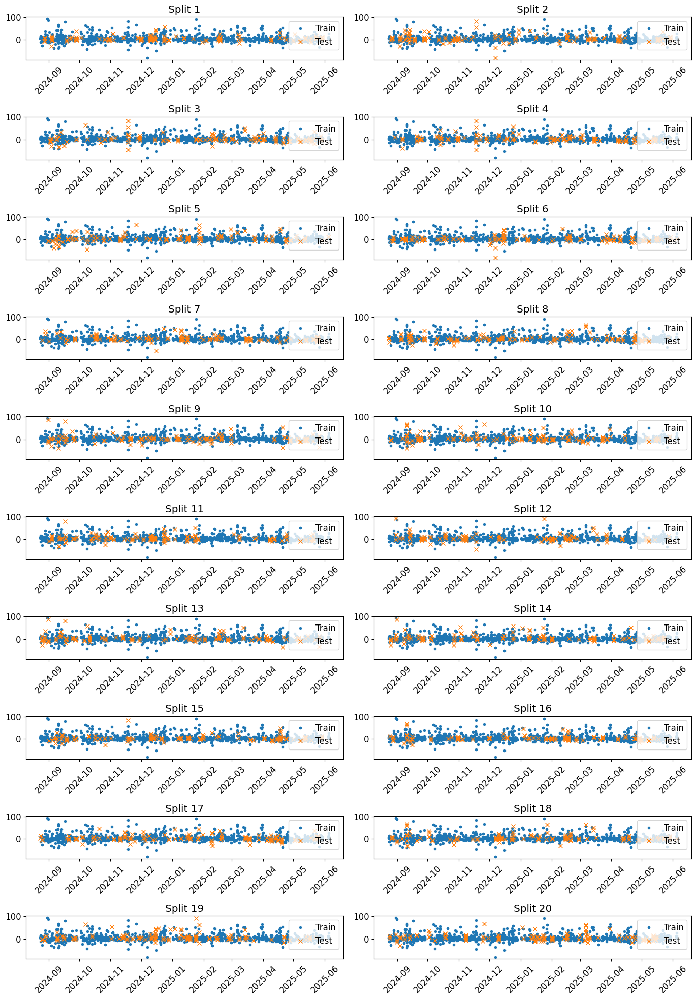

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_84_QCF0
  RMSE:   14.3253
  MAE:    9.1463
  R2:     -0.0061
----------------------------------------
Fitting final model on full training set...


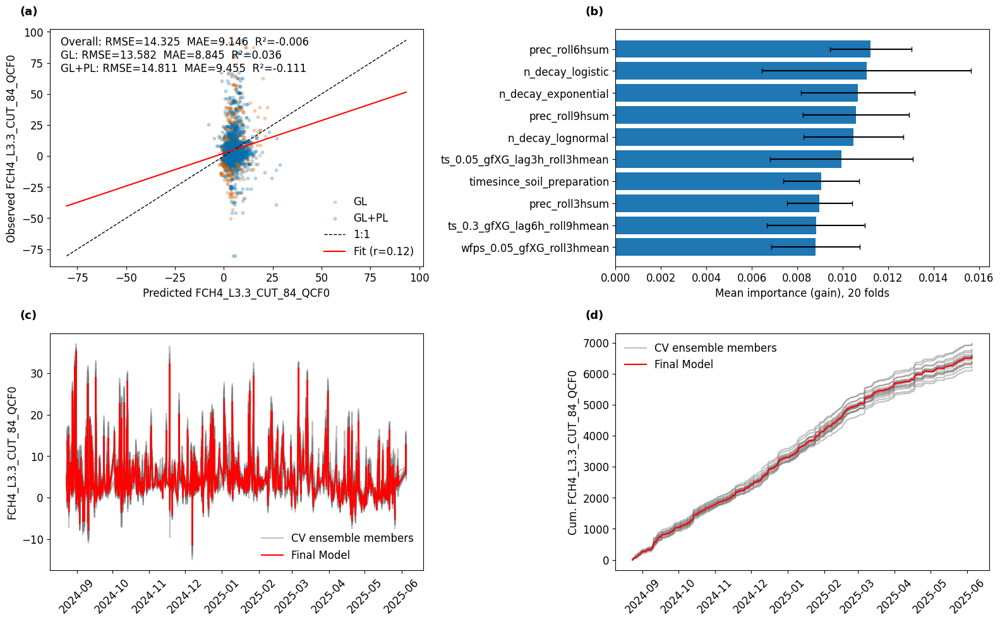

Finished training. Ensemble size (folds): 20


In [14]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

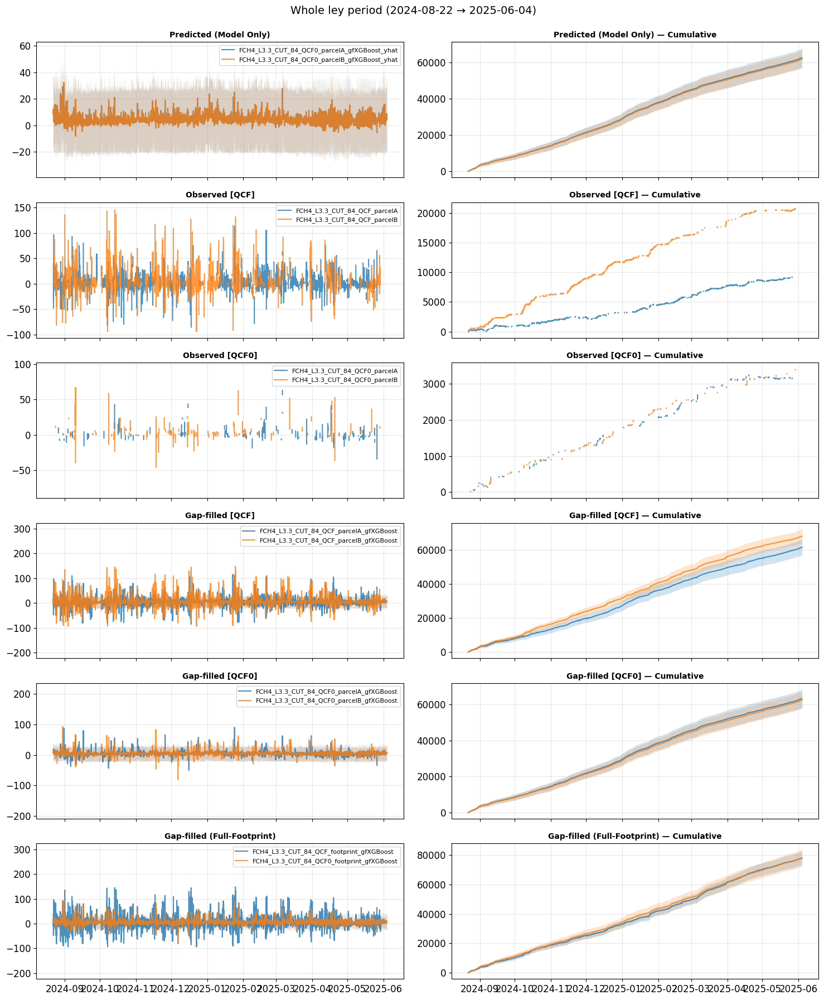

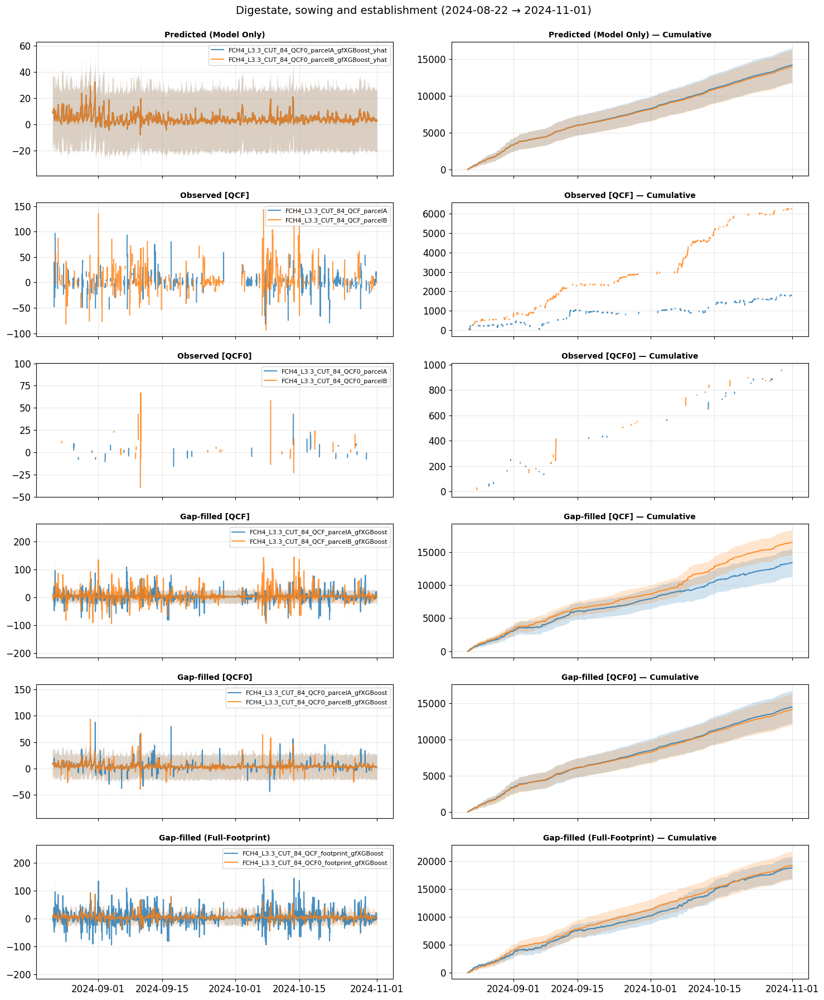

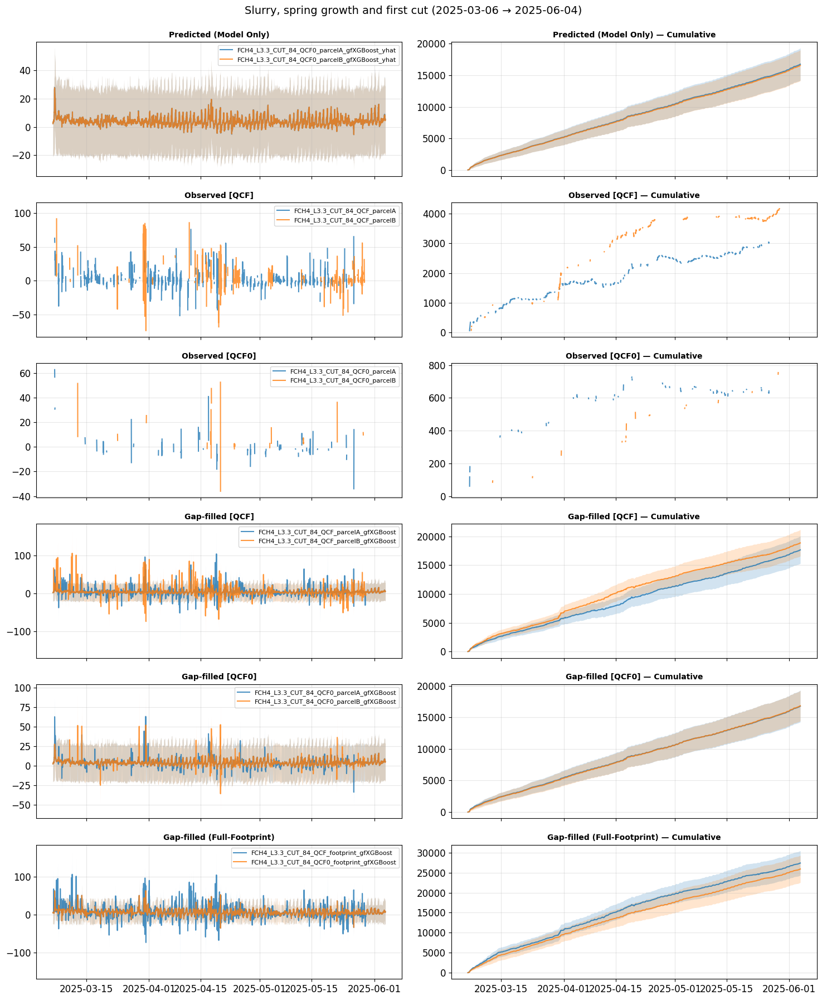

In [15]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT84
df_CUT84 = df_final.copy()

# MERGE RESULTS

In [16]:
newcols_CUT16 = [c for c in df_CUT16.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")
display(newcols_CUT16)

newcols_CUT50 = [c for c in df_CUT50.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")  
display(newcols_CUT50)

newcols_CUT84 = [c for c in df_CUT84.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")     
display(newcols_CUT84)

# Merge the new columns into a single dataframe
gapfilled_df = pd.concat([df_CUT16[newcols_CUT16], df_CUT50[newcols_CUT50], df_CUT84[newcols_CUT84]], axis=1)

gapfilled_df

NEW VARIABLES FROM GAP-FILLING FCH4_L3.3_CUT_84_QCF0:


['FCH4_L3.3_CUT_16_QCF_parcelA',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost',
 'FLAG_FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens06',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens07',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens08',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens09',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens10',
 'FCH4_L3.3_CUT_16

NEW VARIABLES FROM GAP-FILLING FCH4_L3.3_CUT_84_QCF0:


['FCH4_L3.3_CUT_50_QCF_parcelA',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost',
 'FLAG_FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens06',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens07',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens08',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens09',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens10',
 'FCH4_L3.3_CUT_50

NEW VARIABLES FROM GAP-FILLING FCH4_L3.3_CUT_84_QCF0:


['FCH4_L3.3_CUT_84_QCF_parcelA',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_yhat',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost',
 'FLAG_FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ISFILLED',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaGF',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaResid',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaEns',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_total_unc',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaObs',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens00',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens01',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens02',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens03',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens04',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens05',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens06',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens07',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens08',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens09',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens10',
 'FCH4_L3.3_CUT_84

,FCH4_L3.3_CUT_16_QCF_parcelA,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,NaN,11.035021,11.035021,1,14.449279,14.035350,3.433749,14.449279,NaN,11.106040,9.777862,12.664712,10.642375,8.907679,13.291982,...,11.022960,13.334278,13.808910,13.893058,12.751099,10.380890,9.720493,8.375266,13.598948,12.753997,8.666895,12.630897,6.907444,12.856212,10.942675
2024-08-22 00:45:00,25.16086,10.648671,25.160860,0,14.449144,14.035350,3.433179,10.141500,10.14150,10.947703,9.882993,11.934552,10.706130,8.907679,13.146787,...,11.372863,13.562339,14.185448,13.893058,12.942011,10.346745,10.092934,8.354494,13.581390,12.837056,9.418065,12.715677,7.074159,12.713080,10.999074
2024-08-22 01:15:00,NaN,10.663141,10.663141,1,14.456736,14.035350,3.464993,14.456736,NaN,10.960282,9.863363,12.060804,10.706130,8.900914,13.590432,...,11.203362,13.187698,13.808910,13.893058,12.796611,10.380890,9.949841,8.259007,13.628883,12.751821,7.959279,12.334465,6.907444,12.856212,10.469760
2024-08-22 01:45:00,7.09894,10.511826,7.098940,0,14.457113,14.035350,3.466566,4.334050,4.33405,10.947703,9.798040,11.934552,10.706130,8.900914,13.898355,...,11.181481,13.562339,14.185448,13.832404,13.040283,10.353409,10.113001,8.354494,13.550493,13.152560,9.146180,12.558090,7.074159,12.713080,11.026630
2024-08-22 02:15:00,NaN,10.511826,10.511826,1,14.464639,14.035350,3.497821,14.464639,2.06462,10.806620,9.722245,11.934552,10.706130,8.900914,13.898355,...,11.181481,13.562339,14.185448,13.832404,13.040283,10.353409,9.911942,8.354494,13.550493,13.152560,9.146180,12.558090,7.074159,12.474212,10.850618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,NaN,7.640450,7.640450,1,19.052035,18.996500,1.453624,19.052035,NaN,7.511566,6.235992,5.068828,10.442619,6.972102,6.545826,...,6.348952,8.177533,6.870938,8.947726,6.926277,6.814406,7.720705,5.604904,6.846745,7.785724,7.643766,5.713161,6.743453,6.273818,8.769368
2025-06-04 22:15:00,NaN,5.649677,5.649677,1,13.888396,13.845305,1.093190,13.888396,NaN,6.540260,5.557913,4.532315,8.735074,5.027136,5.489254,...,7.604732,8.449996,8.062087,9.899940,10.040489,7.329082,6.952653,5.227229,6.244451,9.449031,7.240996,7.084094,7.138500,6.547401,9.960898
2025-06-04 22:45:00,NaN,5.790778,5.790778,1,13.879042,13.845305,0.967119,13.879042,NaN,6.219218,5.434797,3.737270,7.192534,5.310505,5.897697,...,11.319582,6.546126,5.093612,6.967340,6.713998,4.189205,6.312367,4.724124,5.694854,5.514377,5.131160,6.806500,9.940780,6.304548,6.533747


Cumulative plots to check differences between CUT16, CUT50 and CUT84

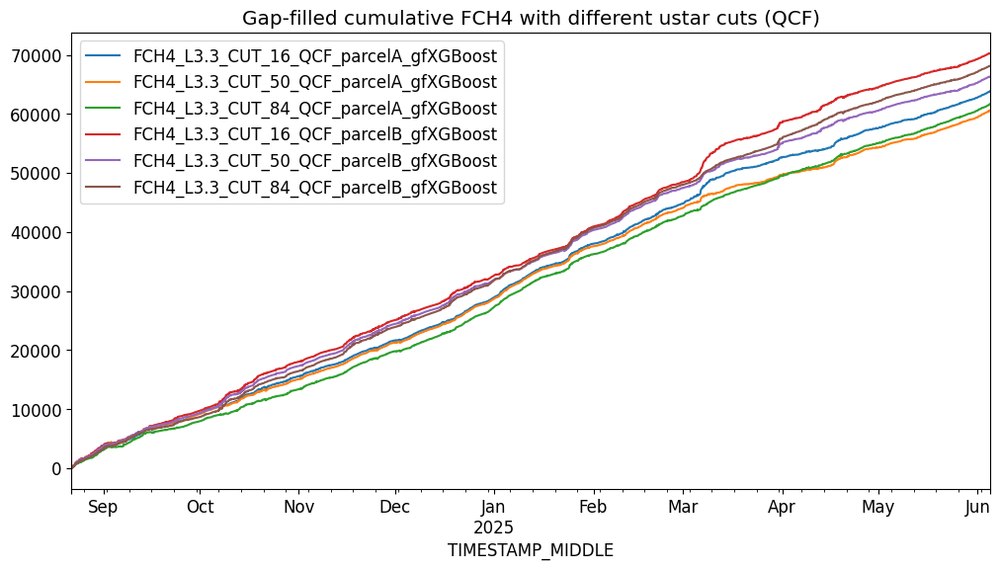

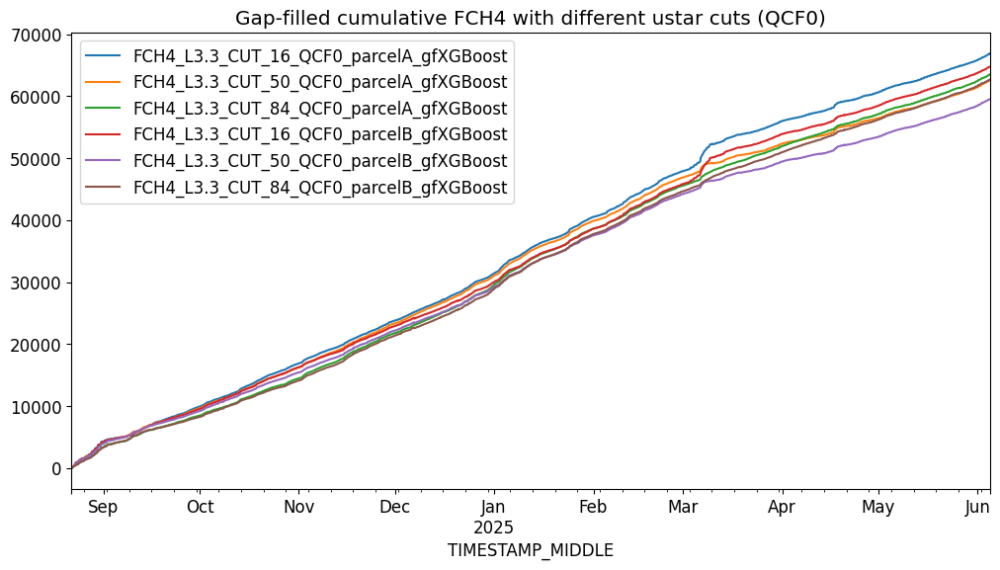

In [17]:
# Plot cumulative fluxes for different ustar cuts and QCF/QCF0
for qcf in ['QCF', 'QCF0']:
    gapfilled_df[
        [
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelA_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelB_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelB_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelB_gf{MODEL_TYPE}'
        ]].cumsum().plot(figsize=(12, 6), title=f'Gap-filled cumulative {TARGET_FLUX} with different ustar cuts ({qcf})')
    plt.show()

# EXPORT

In [18]:
filename = f"83.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = gapfilled_df.copy()
save_parquet(data=df_export, filename=filename)

Saved file 83.4.1_FCH4_GF-XGBoost.parquet (0.826 seconds).


'83.4.1_FCH4_GF-XGBoost.parquet'

# End of notebook

In [19]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-07 14:51:24
